In [46]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [47]:
df = pd.read_csv('multiple_linear_regression_data.csv')
df.head()

,cgpa,iq,placement
0,7.21,144,17.53
1,5.02,90,13.61
2,5.47,93,15.16
3,9.17,85,22.54
4,9.84,112,24.21


In [48]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
x = df.iloc[ : , 0:2]
y = df.iloc[ : , -1]

In [51]:
from sklearn.model_selection import train_test_split 

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression() 

lr.fit(x_train, y_train)

LinearRegression()

In [57]:
lr.predict([[9.17, 85]])

C:\Users\91899\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21.03206363])

In [58]:
y_pred = lr.predict(x_test)
y_pred

array([21.18991122, 13.02070318, 19.68666095, 16.99274268, 15.34017422,
       21.02704311, 20.09371419, 17.92662943, 22.30879026, 19.5567948 ,
       15.65726399, 16.07775012, 21.91193993, 15.0466032 , 17.12105237,
       21.70024376, 18.00471647, 14.31743967, 17.17562065, 20.63481735,
       18.19751845, 17.72190621, 21.67895635, 16.2455217 , 14.59044299,
       16.7356825 , 16.55698829, 16.60904632, 20.10770491, 20.90570637,
       17.82056095, 22.29340495, 20.76284812, 14.43426891, 20.69217481,
       16.13566542, 15.52656109, 15.57371564, 18.16674783, 22.14492352,
       21.66680101, 16.71344129, 20.1159554 , 15.85819942, 16.91955911,
       21.63698419, 22.14759565, 16.09676135, 21.28366249, 19.33150387,
       20.74228042, 15.07012196, 17.37348798, 19.52602419, 21.9319498 ,
       17.12902394, 19.69658495, 22.28850147, 20.24482293, 20.52523998,
       23.20377295, 14.93228423, 17.78460794, 19.27119536, 21.71618691,
       21.98667996, 13.57986378, 21.97252737, 16.75095077, 20.46

C:\Users\91899\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


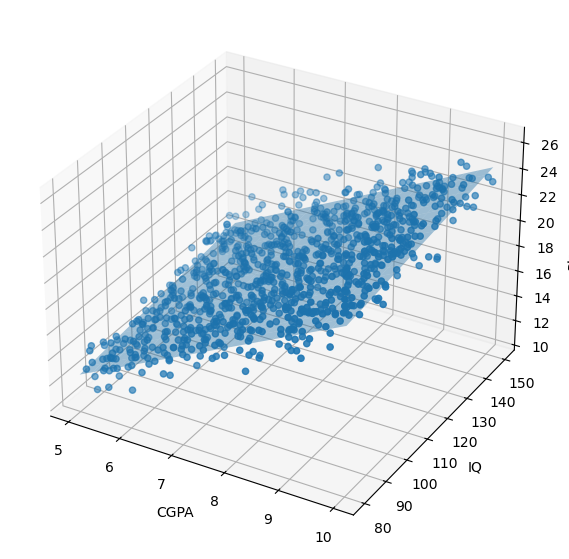

In [60]:
cgpa_range = np.linspace(df['cgpa'].min(), df['cgpa'].max(), 20)
iq_range = np.linspace(df['iq'].min(), df['iq'].max(), 20)

cgpa_grid, iq_grid = np.meshgrid(cgpa_range, iq_range)

plane_points = lr.predict(
    np.column_stack((cgpa_grid.ravel(), iq_grid.ravel()))
).reshape(cgpa_grid.shape)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df['cgpa'], df['iq'], df['placement'])

ax.plot_surface(cgpa_grid, iq_grid, plane_points, alpha=0.4)

ax.set_xlabel("CGPA")
ax.set_ylabel("IQ")
ax.set_zlabel("Placement")

plt.show()